# 2차 EDA

## `01_user_profile_preprocessed.csv`

| 명칭                               | 형식       | 예시                    | 설명                                |
| -------------------------------- | -------- | --------------------- | --------------------------------- |
| `user_id`                        | string   | `U0000001`            | 사용자 고유 ID                         |
| `signup_date`                    | datetime | `2025-01-25`          | 가입일자                              |
| `signup_channel`                 | string   | `오가닉`                 | 가입경로                              |
| `device`                         | string   | `iOS`                 | 사용 기기                             |
| `notification_agreed`            | bool     | `True`                | 알림 수신 동의 여부                       |
| `notification_changed_date`      | datetime | `2025-05-24`          | 알림 수신 동의 변경일자                     |
| `signup_day`                     | date     | `2025-01-25`          | 파생컬럼: 가입일 기준 날짜                   |
| `signup_month`                   | string   | `2025-01`             | 파생컬럼: 가입월                         |
| `signup_weekday`                 | string   | `토`                   | 파생컬럼: 가입요일                        |
| `first_event_time`               | datetime | `2025-01-25 07:25:45` | 파생컬럼: 사용자별 첫 이벤트 발생 시간            |
| `first_event_elapsed_hours`      | float    | `0.43`                | 파생컬럼: 가입 후 첫 이벤트까지 걸린 시간          |
| `first_app_launch_time`          | datetime | `2025-01-25 07:25:45` | 파생컬럼: 사용자별 첫 앱실행 시간               |
| `app_launch_elapsed_hours`       | float    | `0.43`                | 파생컬럼: 가입 후 첫 앱실행까지 걸린 시간          |
| `onboarding_completed_time`      | datetime | `2025-01-25 07:26:15` | 파생컬럼: 사용자별 첫 온보딩 완료 시간            |
| `onboarding_elapsed_hours`       | float    | `0.44`                | 파생컬럼: 가입 후 온보딩 완료까지 걸린 시간         |
| `app_launch_to_onboarding_hours` | float    | `0.01`                | 파생컬럼: 첫 앱실행 후 온보딩 완료까지 걸린 시간      |
| `event_count_total`              | int      | `35`                  | 파생컬럼: 사용자별 전체 이벤트 수               |
| `avg_events_per_session`         | float    | `3.25`                | 파생컬럼: 사용자별 세션당 평균 이벤트 수           |
| `is_signup_log_issue_period`     | bool     | `False`               | 플래그: 로그 수집 장애 기간 가입 여부            |
| `is_no_event_user`               | bool     | `False`               | 플래그: 프로필에는 있지만 이벤트 로그에는 없는 사용자 여부 |
| `is_onboarding_completed`        | bool     | `True`                | 플래그: 온보딩 완료 여부                    |
| `is_first_event_before_signup`   | bool     | `False`               | 플래그: 첫 이벤트가 가입일보다 빠른지 여부          |

## `02_event_log_preprocessed.csv`

| 명칭                      | 형식       | 예시                    | 설명                      |
| ----------------------- | -------- | --------------------- | ----------------------- |
| `user_id`               | string   | `U0000001`            | 사용자 고유 ID               |
| `event_time`            | datetime | `2025-01-25 07:25:45` | 이벤트 발생 시간               |
| `event_type`            | string   | `앱실행`                 | 이벤트 종류                  |
| `session_id`            | string   | `2858202000`          | 세션 ID, 알림 이벤트는 결측 가능    |
| `notification_type`     | string   | `광고성`                 | 알림 유형, 알림 이벤트에만 값 존재    |
| `event_date`            | date     | `2025-01-25`          | 파생컬럼: 이벤트 발생일           |
| `event_month`           | string   | `2025-01`             | 파생컬럼: 이벤트 발생월           |
| `event_weekday`         | string   | `토`                   | 파생컬럼: 이벤트 발생요일          |
| `event_hour`            | int      | `7`                   | 파생컬럼: 이벤트 발생 시간대        |
| `is_log_issue_period`   | bool     | `False`               | 플래그: 로그 수집 장애 기간 이벤트 여부 |
| `is_event_type_missing` | bool     | `False`               | 플래그: 이벤트 종류 결측 여부       |

# 온보딩 퍼널 분석 더 파보기

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

In [117]:
user = pd.read_csv('../../data/processed/01_user_profile_preprocessed.csv', encoding='utf-8-sig')
event = pd.read_csv('../../data/processed/02_Event_Log_preprocessed.csv', encoding='utf-8-sig')

print(user.shape)
print(user.head())

(12500, 23)
    user_id signup_date signup_channel   device notification_agreed  \
0  U0000001  2025-01-25            오가닉      iOS                True   
1  U0000002  2025-05-06            오가닉      iOS               False   
2  U0000003  2025-05-14            오가닉      iOS               False   
3  U0000004  2025-02-23         퍼포먼스광고  Android                True   
4  U0000005  2025-02-18         퍼포먼스광고  Android                True   

  notification_changed_date  signup_day signup_month signup_weekday  \
0                       NaN  2025-01-25      2025-01              토   
1                2025-05-24  2025-05-06      2025-05              화   
2                       NaN  2025-05-14      2025-05              수   
3                       NaN  2025-02-23      2025-02              일   
4                       NaN  2025-02-18      2025-02              화   

      first_event_time  ...  onboarding_completed_time  \
0  2025-01-25 07:25:45  ...        2025-01-25 07:26:15   
1  2025-05-06 16:2

In [118]:
# 온보딩 완료한 유저와 완료하지 않은 유저의 수 확인
print(user['is_onboarding_completed'].value_counts())
print(f"\n온보딩 완료율: {user['is_onboarding_completed'].sum() / len(user) * 100:.1f}%")

is_onboarding_completed
False    6781
True     5719
Name: count, dtype: int64

온보딩 완료율: 45.8%


In [119]:
# 미완료 유저의 총 이벤트 수 분포
not_completed = user[user['is_onboarding_completed'] == False]

print(not_completed['event_count_total'].describe())
print("\n이벤트 1~3건 유저 수:")
print((not_completed['event_count_total'] <= 3).sum())

count    6781.000000
mean      122.741778
std       164.772421
min         0.000000
25%        17.000000
50%        43.000000
75%       161.000000
max       697.000000
Name: event_count_total, dtype: float64

이벤트 1~3건 유저 수:
251


**해석**
- 미완료 유저 6,781명의 이벤트 수 분포
- 평균 122건, 중앙값 43건
- 1~3건 유저는 251명(전체 미완료의 3.7%)뿐

→ 온보딩 미완료 유저도 앱을 지속적으로 사용하고 있으므로, 온보딩 UX 문제일 가능성이 높음

1. 온보딩 자체가 너무 어렵거나 길어서 못 끝냄
   → 온보딩 UX 문제  ← 이쪽 가능성 높아짐

2. 앱 켜자마자 흥미 없어서 그냥 나간 것
   → 앱 자체 문제    ← 가능성 낮아짐

In [120]:
# 미완료 유저들의 이벤트 종류 확인
not_completed_ids = user[user['is_onboarding_completed'] == False]['user_id']

event_not_completed = event[event['user_id'].isin(not_completed_ids)]
print(event_not_completed['event_type'].value_counts())

event_type
앱실행       344116
수면기록      117510
알림수신       93368
운동기록       62106
마음챙김       61794
식단기록       48121
챌린지참여      45809
챌린지_탐색     36688
알림오픈       10253
Name: count, dtype: int64


온보딩을 완료하지 않았음에도 앱의 핵심 기능(수면기록, 운동기록, 식단기록 등)을 전부 사용하고 있다.

→ 온보딩이 필수가 아닌 선택 구조이므로, 유저가 건너뛰고도 앱을 정상적으로 이용할 수 있어 완료율이 45.8%에 머무는 것으로 보인다.

인사이트:
온보딩이 선택적 구조이기 때문에 완료율이 낮고, 온보딩 미완료 유저는 D30 리텐션이 20.1%로 완료 유저(29.5%)보다 낮다. 온보딩을 필수 과정으로 강화하거나 완료 유도 장치가 필요하다

그럼 온보딩을 완료한 유저 5,719명은 언제 완료했을까?

In [121]:
completed = user[user['is_onboarding_completed'] == True]
print(completed['onboarding_elapsed_hours'].describe())

count    5719.000000
mean       14.857077
std         4.609902
min         6.984722
25%        10.870694
50%        14.721667
75%        18.839028
max        23.007778
Name: onboarding_elapsed_hours, dtype: float64


온보딩을 완료한 유저 5,719명은 전원이 가입 당일 24시간 이내에 완료했다.

**온보딩 골든타임: 가입 당일**

당일을 넘기면 온보딩 완료 확률이 0%에 수렴한다.

전략 제안: 가입 후 24시간 이내에 온보딩 완료를 유도하는 푸시알림 또는 인앱 메시지 발송

In [122]:
# 실제 데이터로 확인
sample = user[user['is_onboarding_completed'] == True][['user_id', 'signup_date', 'onboarding_completed_time', 'onboarding_elapsed_hours']].head(10)
print(sample.to_string())

     user_id signup_date onboarding_completed_time  onboarding_elapsed_hours
0   U0000001  2025-01-25       2025-01-25 07:26:15                  7.437500
4   U0000005  2025-02-18       2025-02-18 12:53:07                 12.885278
7   U0000008  2025-02-27       2025-02-27 15:43:25                 15.723611
11  U0000012  2025-04-21       2025-04-21 14:59:29                 14.991389
12  U0000013  2025-01-08       2025-01-08 07:31:10                  7.519444
17  U0000018  2025-05-11       2025-05-11 15:21:24                 15.356667
18  U0000019  2025-02-11       2025-02-11 18:55:10                 18.919444
19  U0000020  2025-02-07       2025-02-07 16:23:16                 16.387778
21  U0000022  2025-05-24       2025-05-24 12:51:42                 12.861667
24  U0000025  2025-05-11       2025-05-11 17:19:33                 17.325833


In [123]:
user.info()

<class 'pandas.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         12500 non-null  str    
 1   signup_date                     12500 non-null  str    
 2   signup_channel                  12363 non-null  str    
 3   device                          12379 non-null  str    
 4   notification_agreed             12384 non-null  object 
 5   notification_changed_date       1976 non-null   str    
 6   signup_day                      12500 non-null  str    
 7   signup_month                    12500 non-null  str    
 8   signup_weekday                  12500 non-null  str    
 9   first_event_time                12453 non-null  str    
 10  first_event_elapsed_hours       12453 non-null  float64
 11  first_app_launch_time           12447 non-null  str    
 12  app_launch_elapsed_hours        12447 non-n

In [124]:
event.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757262 entries, 0 to 1757261
Data columns (total 11 columns):
 #   Column                 Dtype
---  ------                 -----
 0   user_id                str  
 1   event_time             str  
 2   event_type             str  
 3   session_id             str  
 4   notification_type      str  
 5   event_date             str  
 6   event_month            str  
 7   event_weekday          str  
 8   event_hour             int64
 9   is_log_issue_period    bool 
 10  is_event_type_missing  bool 
dtypes: bool(2), int64(1), str(8)
memory usage: 124.0 MB


# 가입 후 정확히 30일째 되는 날 앱을 켠 유저가 몇 %인지 확인

- 가입일자 기준으로 +30일 된 날에
- 앱실행 이벤트가 있으면 → D30 리텐션 카운트

In [125]:
# 날짜 타입 변환
user['signup_date'] = pd.to_datetime(user['signup_date'])
event['event_time'] = pd.to_datetime(event['event_time'])
event['event_date'] = pd.to_datetime(event['event_date'])

# 유저별 가입일자 붙이기
event_with_signup = event.merge(
    user[['user_id', 'signup_date', 'is_onboarding_completed']],
    on='user_id',
    how='left'
)

# 가입일로부터 며칠째인지 계산
event_with_signup['days_since_signup'] = (
    event_with_signup['event_date'] - event_with_signup['signup_date']
).dt.days

print(event_with_signup[['user_id', 'signup_date', 'event_date', 'days_since_signup']].head(10))

    user_id signup_date event_date  days_since_signup
0  U0000001  2025-01-25 2025-01-25                  0
1  U0000001  2025-01-25 2025-01-25                  0
2  U0000001  2025-01-25 2025-01-25                  0
3  U0000001  2025-01-25 2025-01-25                  0
4  U0000001  2025-01-25 2025-01-25                  0
5  U0000001  2025-01-25 2025-01-26                  1
6  U0000001  2025-01-25 2025-01-26                  1
7  U0000001  2025-01-25 2025-01-26                  1
8  U0000001  2025-01-25 2025-01-26                  1
9  U0000001  2025-01-25 2025-01-26                  1


In [126]:
# 앱실행 이벤트만 필터
app_launch = event_with_signup[event_with_signup['event_type'] == '앱실행']

# 온보딩 완료 여부별 D30 리텐션
result = []

for group_name, group_df in app_launch.groupby('is_onboarding_completed'):
    total = group_df['user_id'].nunique()
    d30 = group_df[group_df['days_since_signup'] == 30]['user_id'].nunique()
    retention = d30 / total * 100
    
    result.append({
        '온보딩여부': '완료' if group_name else '미완료',
        '전체유저수': total,
        'D30유저수': d30,
        'D30리텐션(%)': round(retention, 1)
    })

print(pd.DataFrame(result))

  온보딩여부  전체유저수  D30유저수  D30리텐션(%)
0   미완료   6731    1352       20.1
1    완료   5716    1685       29.5


해석 1 (인과관계):
온보딩을 완료했기 때문에
→ 앱 사용법을 제대로 알게 됨
→ 앱이 재미있어짐
→ 30일 뒤에도 계속 씀

해석 2 (상관관계):
원래 앱에 관심 많은 유저가
→ 온보딩도 완료하고
→ 30일 뒤에도 계속 씀
→ 온보딩이 원인이 아닐 수도 있음

온보딩 완료가 리텐션과 강한 상관관계를 보이므로, 온보딩 완료 유도 전략이 유효할 것으로 판단된다. 단, 인과관계 검증을 위해서는 A/B 테스트가 필요하다.

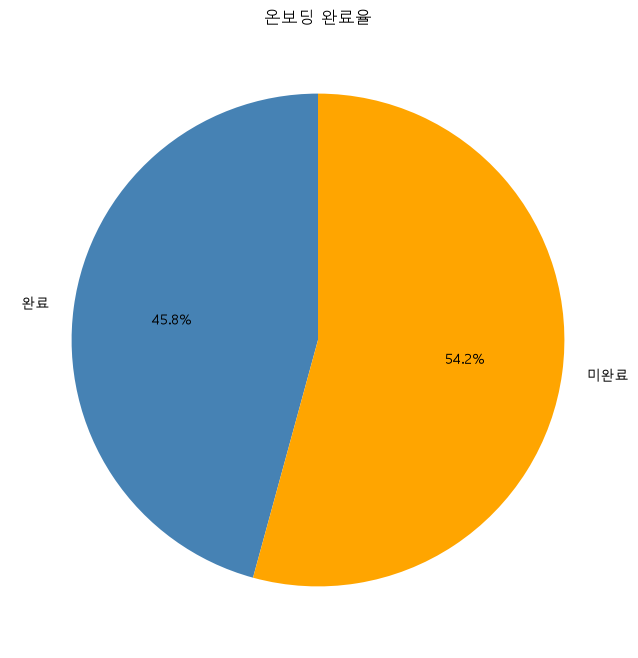

In [127]:
completed_counts = user['is_onboarding_completed'].value_counts()
labels = ['완료', '미완료']
sizes = [completed_counts[True], completed_counts[False]]
colors = ['steelblue', 'orange']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title('온보딩 완료율')
plt.show()

절반 이상이 온보딩 완료 못함

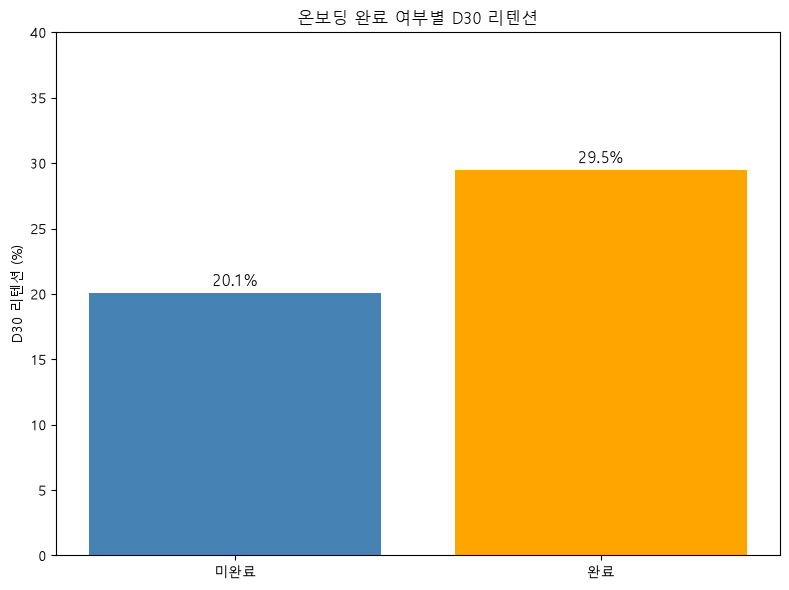

In [128]:
result_df = pd.DataFrame(result)
categories = result_df['온보딩여부'].tolist()
values = result_df['D30리텐션(%)'].tolist()
colors = ['steelblue', 'orange']

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, values, color=colors)
plt.title('온보딩 완료 여부별 D30 리텐션')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 40)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

- 온보딩 완료율 45.8% (절반도 안 됨)
         ↓
- 온보딩 완료 유저 D30 29.5%
- 온보딩 미완료 유저 D30 20.1%
         ↓
- 온보딩 완료 시 D30이 1.5배 높다

# 온보딩 완료 시각대별 D30 리텐션 분석

> ⚠️ `signup_date`는 날짜 정보만 존재(시각 없음)하므로, `onboarding_elapsed_hours`는 가입일 자정(00:00)으로부터의 시간 = **온보딩 완료 시각대**를 의미함. 가입 후 경과 시간이 아님.

온보딩 완료 시각대 구간 정의 (= 당일 몇 시에 완료했는가):

- 9시간 이내  → 자정~오전 9시 완료
- 9~15시간  → 오전 9시~오후 3시 완료
- 15~20시간 → 오후 3시~오후 8시 완료
- 20~24시간 → 오후 8시~자정 완료
- 미완료     → 온보딩 안 함

In [129]:
# onboarding_elapsed_hours = 가입일 자정(00:00)으로부터의 시간 = 완료 시각대
def classify_onboarding_hour(row):
    if not row['is_onboarding_completed']:
        return '미완료'
    hours = row['onboarding_elapsed_hours']
    if hours <= 9:
        return '자정~오전 9시'    # 자정~오전 9시
    elif hours <= 15:
        return '오전 9시~오후 3시'     # 오전 9시~오후 3시
    elif hours <= 20:
        return '오후 3시~오후 8시'    # 오후 3시~오후 8시
    else:
        return '오후 8시~자정'    # 오후 8시~자정

user['온보딩시각대'] = user.apply(classify_onboarding_hour, axis=1)

print("=== 온보딩 완료 시각대별 유저 수 ===")
print(user['온보딩시각대'].value_counts())

=== 온보딩 완료 시각대별 유저 수 ===
온보딩시각대
미완료            6781
오전 9시~오후 3시    2213
오후 3시~오후 8시    1747
오후 8시~자정       1015
자정~오전 9시        744
Name: count, dtype: int64


In [130]:
# 가입일자 붙이기
event_with_signup = event.merge(
    user[['user_id', 'signup_date', '온보딩시각대']],
    on='user_id',
    how='left'
)

# 가입 후 며칠째인지 계산
event_with_signup['days_since_signup'] = (
    event_with_signup['event_date'] - event_with_signup['signup_date']
).dt.days

# 앱실행만 필터
app_launch = event_with_signup[event_with_signup['event_type'] == '앱실행']

# 시각대별 D30 리텐션
result = []
order = ['자정~오전 9시', '오전 9시~오후 3시', '오후 3시~오후 8시', '오후 8시~자정', '미완료']

for group in order:
    group_df = app_launch[app_launch['온보딩시각대'] == group]
    total = group_df['user_id'].nunique()
    d30 = group_df[group_df['days_since_signup'] == 30]['user_id'].nunique()
    retention = d30 / total * 100 if total > 0 else 0
    result.append({
        '시각대': group,
        '유저수': total,
        'D30리텐션(%)': round(retention, 1)
    })

print(pd.DataFrame(result))

           시각대   유저수  D30리텐션(%)
0     자정~오전 9시   742       26.0
1  오전 9시~오후 3시  2213       31.1
2  오후 3시~오후 8시  1747       29.5
3     오후 8시~자정  1014       28.4
4          미완료  6731       20.1


오전 9시~오후 3시 구간이 D30 리텐션이 가장 높다.

오전 9시~오후 3시(9~15시간 구간)에 온보딩을 완료한 유저의 D30이 31.1%로 가장 높다.

- 해당 시간대는 활동적인 낮 시간대로, 앱에 집중도가 높은 유저일 가능성이 있음
- 단, 시각대와 리텐션의 인과관계는 불명확하며, 가입 시각 정보가 없어 실제 온보딩 소요 시간은 측정 불가

근데 일단 모든 구간이 미완료 보다는 높네.. 그래서 언제 완료했든 간에 온보딩을 완료한 것 자체가 중요한것 같은데..

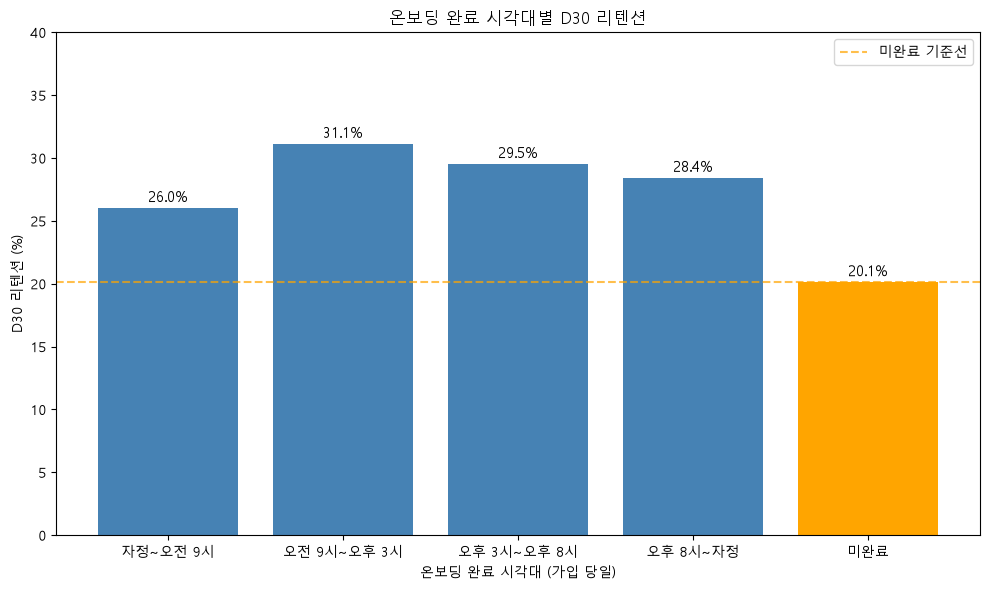

In [131]:
order = ['자정~오전 9시', '오전 9시~오후 3시', '오후 3시~오후 8시', '오후 8시~자정', '미완료']
values = [26.0, 31.1, 29.5, 28.4, 20.1]
colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue', 'orange']

plt.figure(figsize=(10, 6))
bars = plt.bar(order, values, color=colors)
plt.title('온보딩 완료 시각대별 D30 리텐션')
plt.xlabel('온보딩 완료 시각대 (가입 당일)')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 40)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=11)

plt.axhline(y=20.1, color='orange', linestyle='--', alpha=0.7, label='미완료 기준선')
plt.legend()
plt.tight_layout()
plt.show()

1. 온보딩 완료 자체가 중요 → 완료 유도 장치 필요
2. 골든타임은 가입 당일 24시간 이내
3. 오전 9시~오후 3시 완료 유저 D30 31.1%로 최고 → 시각대 효과일 가능성 (가입 시각 데이터 없어 경과 시간 분석 불가)

## 온보딩 퍼널 분석 결과
1. **온보딩 완료율**

   전체 12,500명 중 완료 5,719명 → 45.8%
   절반 이상(54.2%)이 온보딩 미완료

2. **미완료 유저 행동 패턴**

   미완료 유저 평균 이벤트 수 122건, 1~3건 유저는 251명(3.7%)뿐
   → 온보딩 건너뛰고도 앱 핵심 기능 전부 사용 가능한 선택적 구조

3. **온보딩 골든타임**

   완료 유저 전원이 가입 당일 24시간 이내 완료
   당일을 넘기면 완료 확률 0%에 수렴

4. **D30 리텐션 비교**

   완료 유저: 29.5% / 미완료 유저: 20.1%
   → 완료 시 D30이 1.5배 높음

5. **온보딩 완료 시각대별 D30**

   오전 9시~오후 3시 완료 유저 31.1%로 최고
   모든 완료 구간이 미완료(20.1%)보다 높음
   단, signup_date에 시각 없어 실제 경과 시간 측정 불가 → 시각대 효과로 해석

인사이트: 
온보딩은 가입 당일이 골든타임이며, 완료 여부가 D30 리텐션의 핵심 분기점인것 같다.

# 세그먼트별 온보딩 완료율

어떤 유저가 온보딩을 더 잘 완료했는지?

볼 세그먼트:

1. iOS vs Android
2. 오가닉 vs 퍼포먼스광고
3. 알림 동의 vs 미동의

In [132]:
# 세그먼트별 온보딩 완료율
segments = ['device', 'signup_channel', 'notification_agreed']
segment_names = ['기기', '가입경로', '알림동의여부']

for seg, name in zip(segments, segment_names):
    print(f"\n=== {name}별 온보딩 완료율 ===")
    result = user.groupby(seg)['is_onboarding_completed'].agg(['sum', 'count'])
    result.columns = ['완료수', '전체수']
    result['완료율(%)'] = (result['완료수'] / result['전체수'] * 100).round(1)
    print(result)


=== 기기별 온보딩 완료율 ===
          완료수   전체수  완료율(%)
device                     
Android  2392  5204    46.0
iOS      3275  7175    45.6

=== 가입경로별 온보딩 완료율 ===
                 완료수   전체수  완료율(%)
signup_channel                    
오가닉             2482  5511    45.0
퍼포먼스광고          3178  6852    46.4

=== 알림동의여부별 온보딩 완료율 ===
                      완료수   전체수  완료율(%)
notification_agreed                    
False                2079  4400    47.2
True                 3583  7984    44.9


- iOS든 Android든 → 완료율 비슷
- 오가닉이든 광고든 → 완료율 비슷
- 알림 동의든 아니든 → 완료율 비슷

→ 특정 유저 그룹이 온보딩을 못 하는 게 아니라

→ 모든 유저가 온보딩을 50% 확률로 완료 못 하는 것

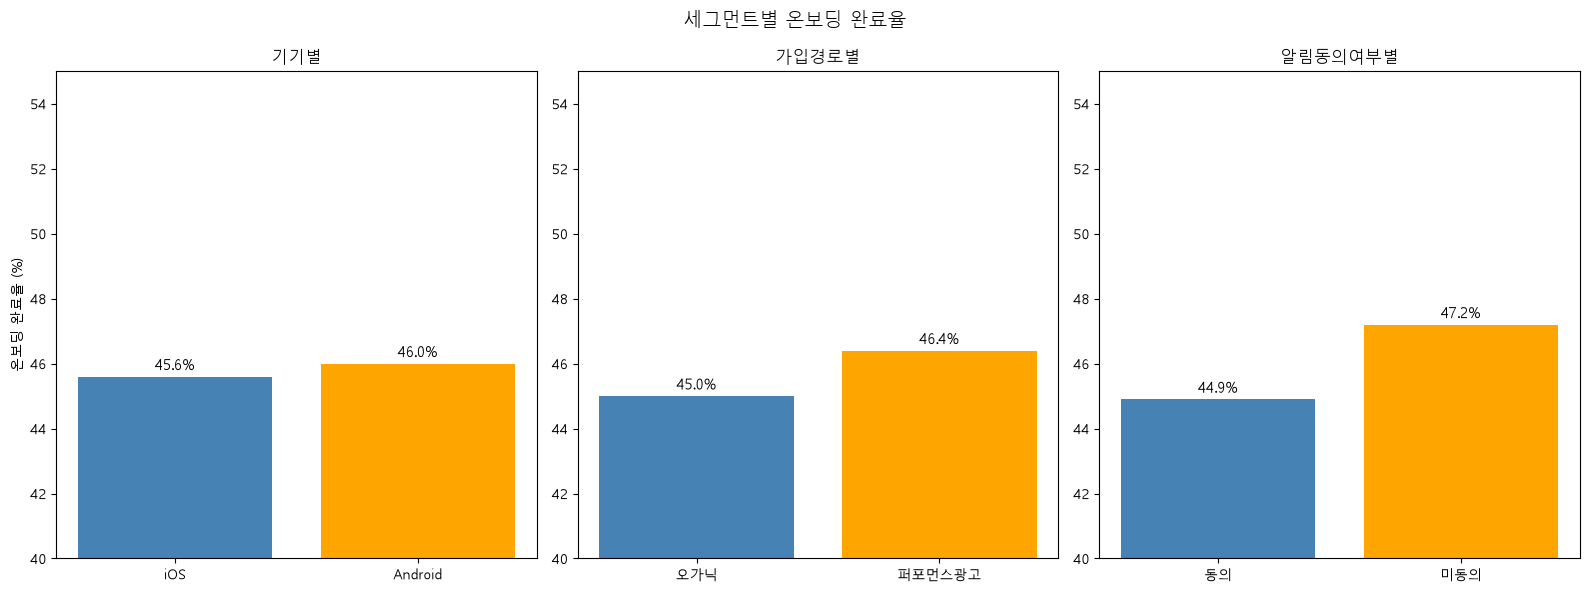

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('세그먼트별 온보딩 완료율', fontsize=14)

# 1. 기기별
device_data = {'iOS': 45.6, 'Android': 46.0}
axes[0].bar(device_data.keys(), device_data.values(), color=['steelblue', 'orange'])
axes[0].set_title('기기별')
axes[0].set_ylabel('온보딩 완료율 (%)')
axes[0].set_ylim(40, 55)
for i, (k, v) in enumerate(device_data.items()):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontsize=11)

# 2. 가입경로별
channel_data = {'오가닉': 45.0, '퍼포먼스광고': 46.4}
axes[1].bar(channel_data.keys(), channel_data.values(), color=['steelblue', 'orange'])
axes[1].set_title('가입경로별')
axes[1].set_ylim(40, 55)
for i, (k, v) in enumerate(channel_data.items()):
    axes[1].text(i, v + 0.2, f'{v}%', ha='center', fontsize=11)

# 3. 알림동의별
noti_data = {'동의': 44.9, '미동의': 47.2}
axes[2].bar(noti_data.keys(), noti_data.values(), color=['steelblue', 'orange'])
axes[2].set_title('알림동의여부별')
axes[2].set_ylim(40, 55)
for i, (k, v) in enumerate(noti_data.items()):
    axes[2].text(i, v + 0.2, f'{v}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

전체 유저 대상으로 온보딩 완료를 유도하는 구조적 개선이 필요하다.

→ 온보딩을 건너뛸 수 없는 필수 과정으로 변경하거나, 가입 당일 내 완료를 유도하는 인앱 메시지/푸시알림 전략 검토

온보딩 완료 후 바로 첫 활동(수면/운동/식단/마음챙김/챌린지)을 한 유저가 그렇지 않은 유저보다 D30이 높은가?

In [134]:
# 첫 활동 이벤트 종류
activity_types = ['수면기록', '운동기록', '식단기록', '마음챙김', '챌린지참여']

# 온보딩 완료 유저만
completed_ids = user[user['is_onboarding_completed'] == True]['user_id']

# 온보딩 완료 유저의 활동 이벤트만
activity_events = event[
    (event['user_id'].isin(completed_ids)) &
    (event['event_type'].isin(activity_types))
]

# 유저별 첫 활동 시간
first_activity = activity_events.groupby('user_id')['event_time'].min().reset_index()
first_activity.columns = ['user_id', '첫활동시간']

print(f"온보딩 완료 유저: {len(completed_ids)}명")
print(f"첫 활동 경험 유저: {len(first_activity)}명")
print(f"첫 활동 미경험 유저: {len(completed_ids) - len(first_activity)}명")

온보딩 완료 유저: 5719명
첫 활동 경험 유저: 5674명
첫 활동 미경험 유저: 45명


# 온보딩 완료 시간에 따른 잔존율
# 온보딩갭구간은 해석실수로 다시 확인해봐야 할듯

In [135]:
# 실제 온보딩 소요시간 다시 계산
user['실제온보딩소요시간'] = (
    pd.to_datetime(user['onboarding_completed_time']) - 
    pd.to_datetime(user['first_app_launch_time'])
).dt.total_seconds() / 60

# 마이너스 제외
completed = user[
    (user['is_onboarding_completed'] == True) &
    (user['실제온보딩소요시간'] >= 0)
]

print(f"온보딩 완료 유저 수: {len(completed)}명")

온보딩 완료 유저 수: 5656명


1. 온보딩이 정말 짧아서 30초면 완료 가능
2. first_app_launch_time이랑 onboarding_completed_time이
   거의 같은 시각이라 차이가 0에 수렴

In [136]:
# 0.5분(30초) 유저 샘플 보기
fast = completed[completed['실제온보딩소요시간'] <= 1]
print(f"1분 이내 유저: {len(fast)}명")
print(fast[['user_id', 'first_app_launch_time', 'onboarding_completed_time', '실제온보딩소요시간']].head(20).to_string())

1분 이내 유저: 2240명
     user_id first_app_launch_time onboarding_completed_time  실제온보딩소요시간
0   U0000001   2025-01-25 07:25:45       2025-01-25 07:26:15        0.5
4   U0000005   2025-02-18 12:52:37       2025-02-18 12:53:07        0.5
7   U0000008   2025-02-27 15:42:55       2025-02-27 15:43:25        0.5
12  U0000013   2025-01-08 07:30:40       2025-01-08 07:31:10        0.5
17  U0000018   2025-05-11 15:20:54       2025-05-11 15:21:24        0.5
19  U0000020   2025-02-07 16:22:46       2025-02-07 16:23:16        0.5
21  U0000022   2025-05-24 12:51:12       2025-05-24 12:51:42        0.5
25  U0000026   2025-05-17 15:18:59       2025-05-17 15:19:29        0.5
28  U0000029   2025-01-28 14:23:39       2025-01-28 14:24:09        0.5
29  U0000030   2025-01-03 15:53:56       2025-01-03 15:54:26        0.5
30  U0000031   2025-02-13 08:43:45       2025-02-13 08:44:15        0.5
37  U0000038   2025-04-14 21:06:58       2025-04-14 21:07:28        0.5
39  U0000040   2025-02-18 07:08:11       2025-02

가상데이터 한계인거 같은데 왜다 딱 30초냐...

In [137]:
def classify_onboarding_time(minutes):
    if minutes <= 1:
        return '1분 이내'
    elif minutes <= 3:
        return '1~3분'
    elif minutes <= 5:
        return '3~5분'
    elif minutes <= 10:
        return '5~10분'
    elif minutes <= 30:
        return '10~30분'
    else:
        return '30분 이상'

completed['소요시간구간'] = completed['실제온보딩소요시간'].apply(classify_onboarding_time)

print("=== 소요시간 구간별 분포 ===")
order = ['1분 이내', '1~3분', '3~5분', '5~10분', '10~30분', '30분 이상']
for g in order:
    count = (completed['소요시간구간'] == g).sum()
    pct = count / len(completed) * 100
    print(f"  {g}: {count:,}명 ({pct:.1f}%)")

=== 소요시간 구간별 분포 ===
  1분 이내: 2,240명 (39.6%)
  1~3분: 13명 (0.2%)
  3~5분: 10명 (0.2%)
  5~10분: 24명 (0.4%)
  10~30분: 107명 (1.9%)
  30분 이상: 3,262명 (57.7%)


In [138]:
# 소요시간구간 completed에서 app_launch에 붙이기
event_with_signup = event.merge(
    completed[['user_id', 'signup_date', '소요시간구간']],
    on='user_id',
    how='left'
)

event_with_signup['days_since_signup'] = (
    pd.to_datetime(event_with_signup['event_date']) - 
    pd.to_datetime(event_with_signup['signup_date'])
).dt.days

app_launch = event_with_signup[event_with_signup['event_type'] == '앱실행']

# 구간별 D30
result = []
order = ['1분 이내', '1~3분', '3~5분', '5~10분', '10~30분', '30분 이상']

for group in order:
    group_df = app_launch[app_launch['소요시간구간'] == group]
    total = group_df['user_id'].nunique()
    d30 = group_df[group_df['days_since_signup'] == 30]['user_id'].nunique()
    retention = d30 / total * 100 if total > 0 else 0
    result.append({'구간': group, '유저수': total, 'D30(%)': round(retention, 1)})

print(pd.DataFrame(result))

       구간   유저수  D30(%)
0   1분 이내  2240    26.2
1    1~3분    13     7.7
2    3~5분    10    40.0
3   5~10분    24    29.2
4  10~30분   107    29.0
5  30분 이상  3262    31.9


앱실행 직후 바로 온보딩 완료한 유저(26.2%)보다

시간을 두고 온보딩 완료한 유저(31.9%)의 D30이 더 높다

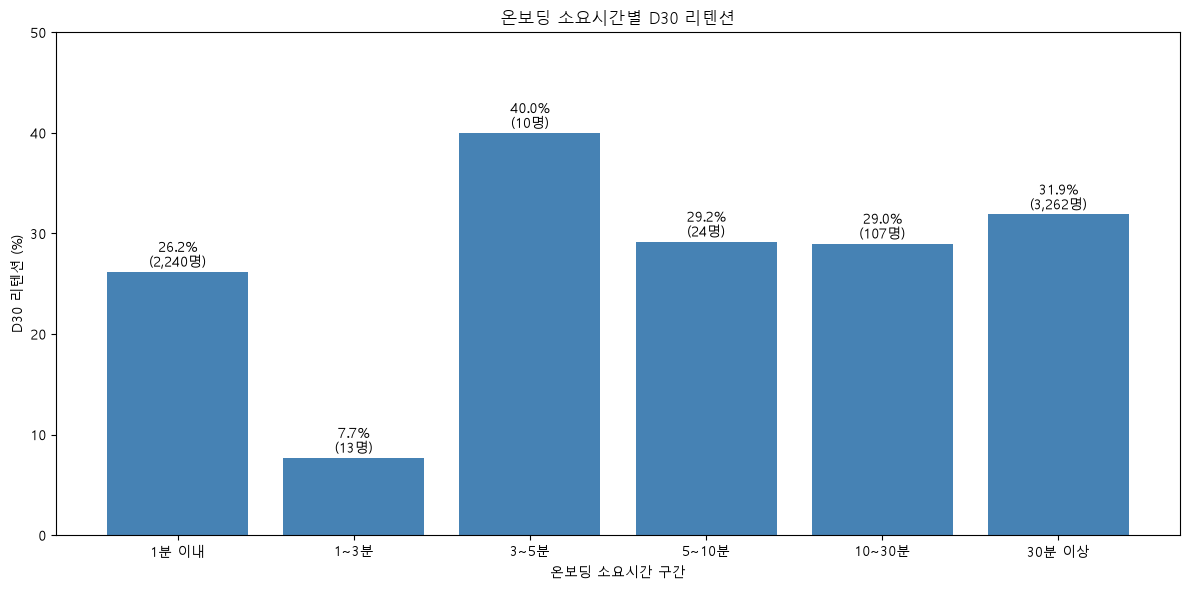

In [139]:
order = ['1분 이내', '1~3분', '3~5분', '5~10분', '10~30분', '30분 이상']
values = [26.2, 7.7, 40.0, 29.2, 29.0, 31.9]
users = [2240, 13, 10, 24, 107, 3262]
colors = ['steelblue'] * 6

plt.figure(figsize=(12, 6))
bars = plt.bar(order, values, color=colors)
plt.title('온보딩 소요시간별 D30 리텐션')
plt.xlabel('온보딩 소요시간 구간')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 50)

for bar, val, n in zip(bars, values, users):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%\n({n:,}명)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

1. 온보딩 완료 유저 필터
2. 완료 직후 첫 활동 이벤트 찾기
3. 첫 활동 여부에 따라 그룹 나누기
4. 그룹별 D30 비교
5. 시각화

In [140]:
# 활동 이벤트 종류
activity_types = ['수면기록', '운동기록', '식단기록', '마음챙김', '챌린지참여']

# 온보딩 완료 유저의 활동 이벤트만
activity_events = event[
    (event['user_id'].isin(completed_ids)) &
    (event['event_type'].isin(activity_types))
]

# 유저별 첫 활동 시간
first_activity = activity_events.groupby('user_id')['event_time'].min().reset_index()
first_activity.columns = ['user_id', '첫활동시간']

print(f"온보딩 완료 유저: {len(completed_ids)}명")
print(f"첫 활동 경험 유저: {len(first_activity)}명")
print(f"첫 활동 미경험 유저: {len(completed_ids) - len(first_activity)}명")

온보딩 완료 유저: 5719명
첫 활동 경험 유저: 5674명
첫 활동 미경험 유저: 45명


온보딩을 완료했어도 첫 활동을 안 하면 D30이 낮은지?

그룹 1: 온보딩 완료 + 첫 활동 O (5,674명)
그룹 2: 온보딩 완료 + 첫 활동 X (45명)
그룹 3: 온보딩 미완료 (6,781명)

In [141]:
# 그룹 분류
first_activity_ids = set(first_activity['user_id'])
completed_ids_set = set(completed_ids)

def classify_user(row):
    if not row['is_onboarding_completed']:
        return '온보딩 미완료'
    elif row['user_id'] in first_activity_ids:
        return '온보딩완료+첫활동O'
    else:
        return '온보딩완료+첫활동X'

user['온보딩그룹'] = user.apply(classify_user, axis=1)
print(user['온보딩그룹'].value_counts())

온보딩그룹
온보딩 미완료       6781
온보딩완료+첫활동O    5674
온보딩완료+첫활동X      45
Name: count, dtype: int64


각 그룹별 D30 리텐션 계산

In [142]:
# 가입일자 붙이기
event_with_signup = event.merge(
    user[['user_id', 'signup_date', '온보딩그룹']],
    on='user_id',
    how='left'
)

event_with_signup['days_since_signup'] = (
    event_with_signup['event_date'] - 
    pd.to_datetime(event_with_signup['signup_date'])
).dt.days

# 앱실행만
app_launch = event_with_signup[event_with_signup['event_type'] == '앱실행']

# 그룹별 D30
result = []
order = ['온보딩완료+첫활동O', '온보딩완료+첫활동X', '온보딩 미완료']

for group in order:
    group_df = app_launch[app_launch['온보딩그룹'] == group]
    total = group_df['user_id'].nunique()
    d30 = group_df[group_df['days_since_signup'] == 30]['user_id'].nunique()
    retention = d30 / total * 100 if total > 0 else 0
    result.append({
        '그룹': group,
        '유저수': total,
        'D30(%)': round(retention, 1)
    })

print(pd.DataFrame(result))

           그룹   유저수  D30(%)
0  온보딩완료+첫활동O  5671    29.7
1  온보딩완료+첫활동X    45     0.0
2     온보딩 미완료  6731    20.1


- 온보딩 완료 → 첫 활동 O → D30 29.7% 
- 온보딩 완료 → 첫 활동 X → D30 0.0%  
- 온보딩 미완료           → D30 20.1%

온보딩 완료만으로는 부족하다.

온보딩 완료 직후 첫 활동까지 이어져야 장기 잔존이 가능하다

온보딩을 완료했더라도 첫 활동을 하지 않으면 30일까지 남는 유저가 단 한 명도 없다

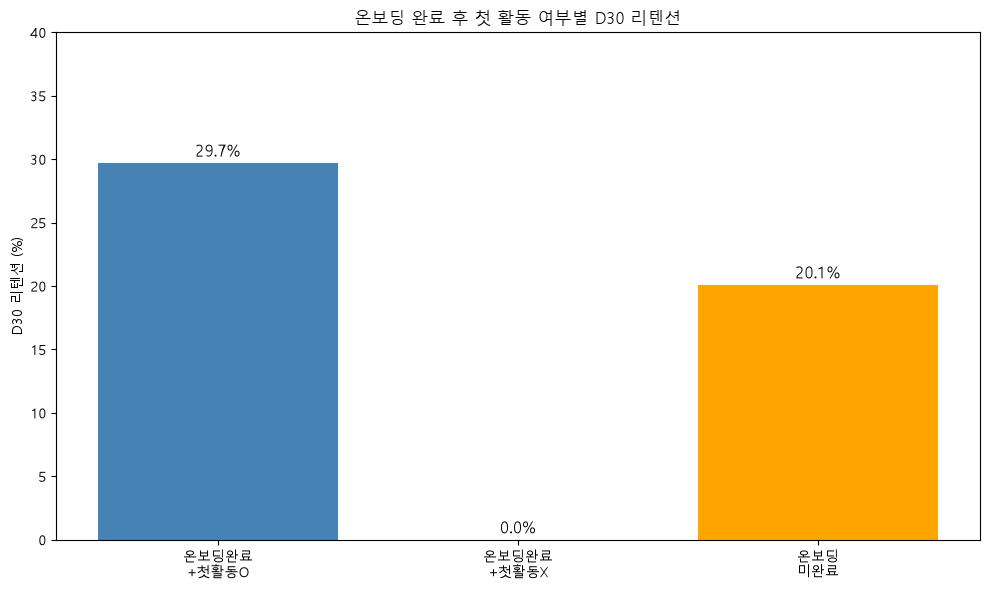

In [143]:
groups = ['온보딩완료\n+첫활동O', '온보딩완료\n+첫활동X', '온보딩\n미완료']
values = [29.7, 0.0, 20.1]
colors = ['steelblue', 'red', 'orange']

plt.figure(figsize=(10, 6))
bars = plt.bar(groups, values, color=colors)
plt.title('온보딩 완료 후 첫 활동 여부별 D30 리텐션')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 40)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

온보딩 완료보단 첫활동이 더 분기점이 될거 같다.

## 온보딩 완료 + 챌린지 참여 유저가 그렇지 않은 유저보다 D30이 높은가?

그룹 1: 온보딩완료 + 챌린지참여 O
그룹 2: 온보딩완료 + 챌린지참여 X
그룹 3: 온보딩미완료 + 챌린지참여 O
그룹 4: 온보딩미완료 + 챌린지참여 X

In [144]:
# 챌린지 참여 유저 추출
challenge_ids = set(
    event[event['event_type'] == '챌린지참여']['user_id'].unique()
)

# 그룹 분류
def classify_challenge_group(row):
    is_completed = row['is_onboarding_completed']
    is_challenge = row['user_id'] in challenge_ids
    
    if is_completed and is_challenge:
        return '온보딩완료+챌린지O'
    elif is_completed and not is_challenge:
        return '온보딩완료+챌린지X'
    elif not is_completed and is_challenge:
        return '온보딩미완료+챌린지O'
    else:
        return '온보딩미완료+챌린지X'

user['챌린지그룹'] = user.apply(classify_challenge_group, axis=1)
print(user['챌린지그룹'].value_counts())

챌린지그룹
온보딩완료+챌린지O     4948
온보딩미완료+챌린지O    4424
온보딩미완료+챌린지X    2357
온보딩완료+챌린지X      771
Name: count, dtype: int64


- 온보딩완료+챌린지O  4,948명 (39.6%) ← 가장 많음
- 온보딩미완료+챌린지O 4,424명 (35.4%)
- 온보딩미완료+챌린지X 2,357명 (18.9%)
- 온보딩완료+챌린지X    771명  (6.2%) ← 가장 적음

온보딩 완료 유저는 챌린지도 참여하는 경향이 높다!

In [145]:
event_with_signup = event.merge(
    user[['user_id', 'signup_date', '챌린지그룹']],
    on='user_id',
    how='left'
)

event_with_signup['days_since_signup'] = (
    event_with_signup['event_date'] - 
    pd.to_datetime(event_with_signup['signup_date'])
).dt.days

app_launch = event_with_signup[event_with_signup['event_type'] == '앱실행']

result = []
order = ['온보딩완료+챌린지O', '온보딩완료+챌린지X', '온보딩미완료+챌린지O', '온보딩미완료+챌린지X']

for group in order:
    group_df = app_launch[app_launch['챌린지그룹'] == group]
    total = group_df['user_id'].nunique()
    d30 = group_df[group_df['days_since_signup'] == 30]['user_id'].nunique()
    retention = d30 / total * 100 if total > 0 else 0
    result.append({'그룹': group, '유저수': total, 'D30(%)': round(retention, 1)})

print(pd.DataFrame(result))

            그룹   유저수  D30(%)
0   온보딩완료+챌린지O  4946    34.0
1   온보딩완료+챌린지X   770     0.6
2  온보딩미완료+챌린지O  4423    30.4
3  온보딩미완료+챌린지X  2308     0.3


1. 챌린지 참여 O:
- 온보딩완료+챌린지O  → 34.0%
- 온보딩미완료+챌린지O → 30.4%

2. 챌린지 참여 X:
- 온보딩완료+챌린지X  → 0.6%
- 온보딩미완료+챌린지X → 0.3%

온보딩 완료 여부보다 챌린지 참여 여부가 D30에 더 결정적이다

전략 제안한다면 챌린지 참여 유도가 리텐션의 핵심.

온보딩 완료 직후 챌린지 참여를 바로 연결하는 플로우 필요

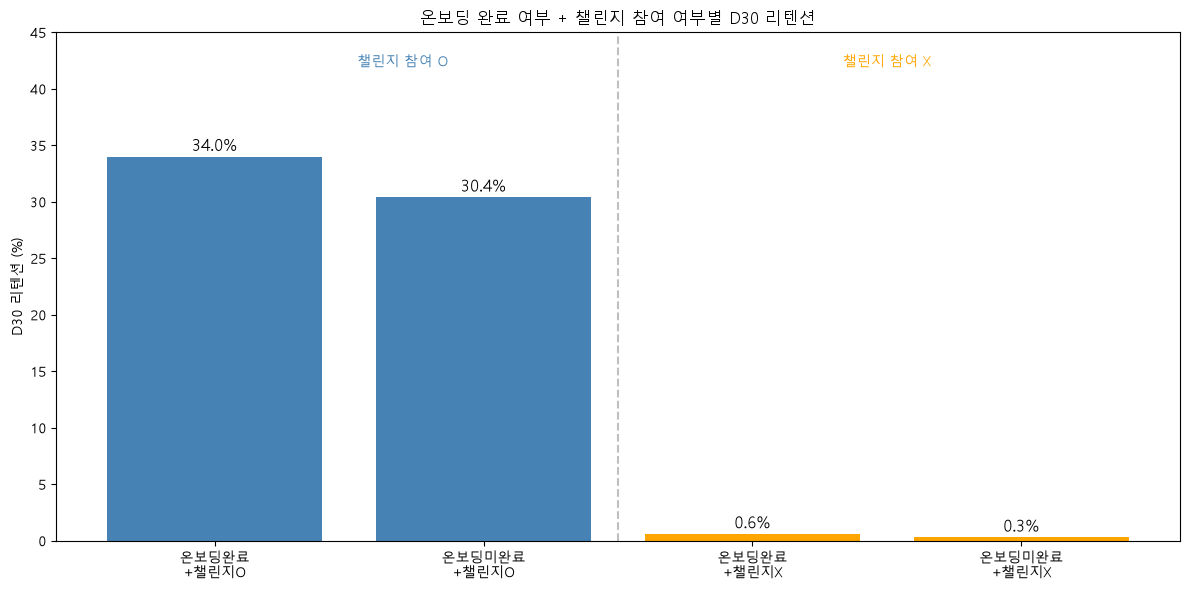

In [146]:
groups = ['온보딩완료\n+챌린지O', '온보딩미완료\n+챌린지O', '온보딩완료\n+챌린지X', '온보딩미완료\n+챌린지X']
values = [34.0, 30.4, 0.6, 0.3]
colors = ['steelblue', 'steelblue', 'orange', 'orange']

plt.figure(figsize=(12, 6))
bars = plt.bar(groups, values, color=colors)
plt.title('온보딩 완료 여부 + 챌린지 참여 여부별 D30 리텐션')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 45)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=12)

# 챌린지 참여/미참여 구분선
plt.axvline(x=1.5, color='gray', linestyle='--', alpha=0.5)
plt.text(0.7, 42, '챌린지 참여 O', ha='center', fontsize=10, color='steelblue')
plt.text(2.5, 42, '챌린지 참여 X', ha='center', fontsize=10, color='orange')

plt.tight_layout()
plt.show()

챌린지 참여 여부가 D30 리텐션의 결정적 분기점이다.

온보딩 완료 여부보다 챌린지 참여 여부가 더 중요하다.

가입 후 며칠 만에 챌린지에 참여했냐에 따라 D30이 다른가?

In [147]:

# 챌린지 참여 이벤트만
challenge_events = event[event['event_type'] == '챌린지참여']

# 유저별 첫 챌린지 참여일
first_challenge = challenge_events.groupby('user_id')['event_date'].min().reset_index()
first_challenge.columns = ['user_id', '첫챌린지일']

# 가입일자 붙이기
first_challenge = first_challenge.merge(
    user[['user_id', 'signup_date']],
    on='user_id',
    how='left'
)

# 가입 후 며칠만에 챌린지 참여했는지
first_challenge['챌린지참여일수'] = (
    pd.to_datetime(first_challenge['첫챌린지일']) - 
    pd.to_datetime(first_challenge['signup_date'])
).dt.days

print("=== 챌린지 참여까지 걸린 일수 ===")
print(first_challenge['챌린지참여일수'].describe())

=== 챌린지 참여까지 걸린 일수 ===
count    9372.000000
mean        2.233995
std         6.289463
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        86.000000
Name: 챌린지참여일수, dtype: float64


- 중앙값: 0일 → 절반 이상이 가입 당일 챌린지 참여
- 75%: 1일 → 75%가 가입 후 1일 이내 참여
- 최대: 86일

In [148]:
def classify_challenge_timing(days):
    if days == 0:
        return '당일'
    elif days <= 3:
        return '1~3일'
    elif days <= 7:
        return '4~7일'
    else:
        return '7일 이후'

first_challenge['챌린지참여구간'] = first_challenge['챌린지참여일수'].apply(classify_challenge_timing)

print("=== 챌린지 참여 시점 구간별 유저 수 ===")
print(first_challenge['챌린지참여구간'].value_counts())

=== 챌린지 참여 시점 구간별 유저 수 ===
챌린지참여구간
당일       6645
1~3일     1087
7일 이후     961
4~7일      679
Name: count, dtype: int64


당일 참여자가 압도적으로 많네..

In [149]:
# 가입일자 붙여서 event에 merge
event_with_challenge = event.merge(
    first_challenge[['user_id', 'signup_date', '챌린지참여구간']],
    on='user_id',
    how='inner'  # 챌린지 참여 유저만
)

event_with_challenge['days_since_signup'] = (
    pd.to_datetime(event_with_challenge['event_date']) - 
    pd.to_datetime(event_with_challenge['signup_date'])
).dt.days

app_launch = event_with_challenge[event_with_challenge['event_type'] == '앱실행']

result = []
order = ['당일', '1~3일', '4~7일', '7일 이후']

for group in order:
    group_df = app_launch[app_launch['챌린지참여구간'] == group]
    total = group_df['user_id'].nunique()
    d30 = group_df[group_df['days_since_signup'] == 30]['user_id'].nunique()
    retention = d30 / total * 100 if total > 0 else 0
    result.append({'구간': group, '유저수': total, 'D30(%)': round(retention, 1)})

print(pd.DataFrame(result))

      구간   유저수  D30(%)
0     당일  6642    31.9
1   1~3일  1087    26.7
2   4~7일   679    27.4
3  7일 이후   961    44.7


당일 참여 유저
→ 호기심에 바로 참여
→ 이탈 가능성도 높음

7일 이후 참여 유저
→ 일주일 동안 앱을 쓰다가 챌린지 발견
→ 이미 앱에 어느 정도 정착한 유저
→ 챌린지까지 참여 → 더 오래 남음

7일 이후 챌린지 참여 유저는 원래부터 앱에 관심이 많은 유저일 가능성이 높다

7일 이후 챌린지 참여 유저의 D30이 44.7%로 가장 높으나, 이는 앱에 이미 정착한 유저가 챌린지를 발견한 것일 수 있어 인과관계 단정은 어렵다.

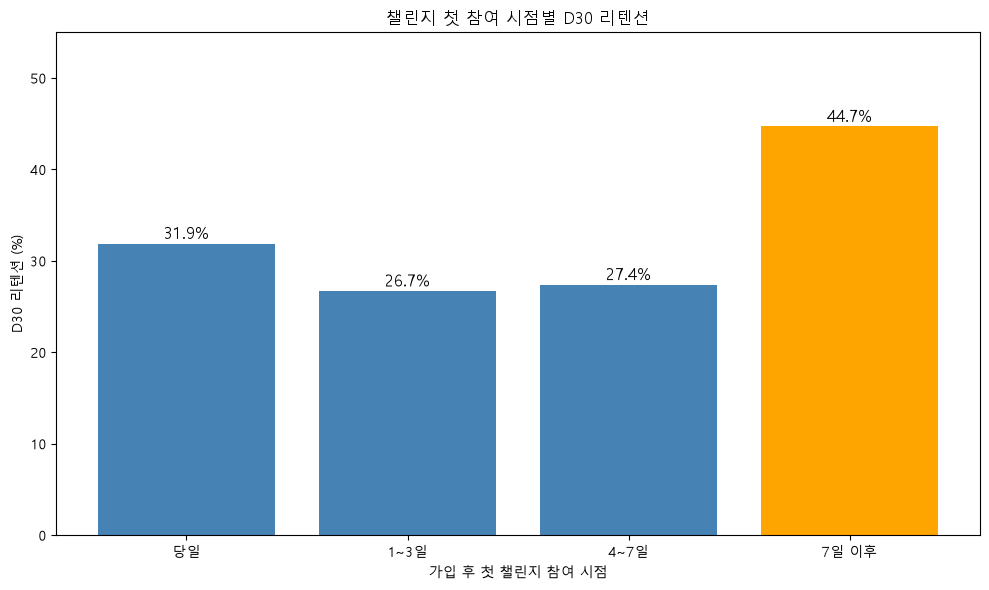

In [150]:
pythonorder = ['당일', '1~3일', '4~7일', '7일 이후']
values = [31.9, 26.7, 27.4, 44.7]
colors = ['steelblue', 'steelblue', 'steelblue', 'orange']

plt.figure(figsize=(10, 6))
bars = plt.bar(order, values, color=colors)
plt.title('챌린지 첫 참여 시점별 D30 리텐션')
plt.xlabel('가입 후 첫 챌린지 참여 시점')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 55)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()